In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_dir / "data" / "propertylens_featured.csv"
visuals_dir = project_dir / "visuals"
visuals_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Rows: 14,225
Columns: 18


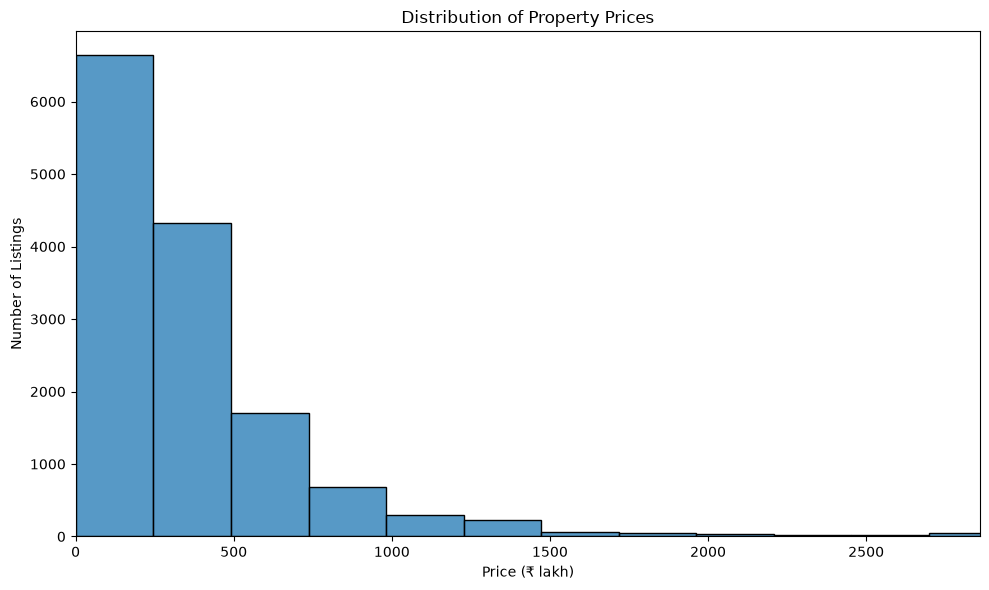

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="price_lakh",
    bins=50,
    ax=ax
)

ax.set_xlim(0, df["price_lakh"].quantile(0.99))
ax.set_title("Distribution of Property Prices")
ax.set_xlabel("Price (₹ lakh)")
ax.set_ylabel("Number of Listings")

plt.tight_layout()
fig.savefig(visuals_dir / "01_property_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

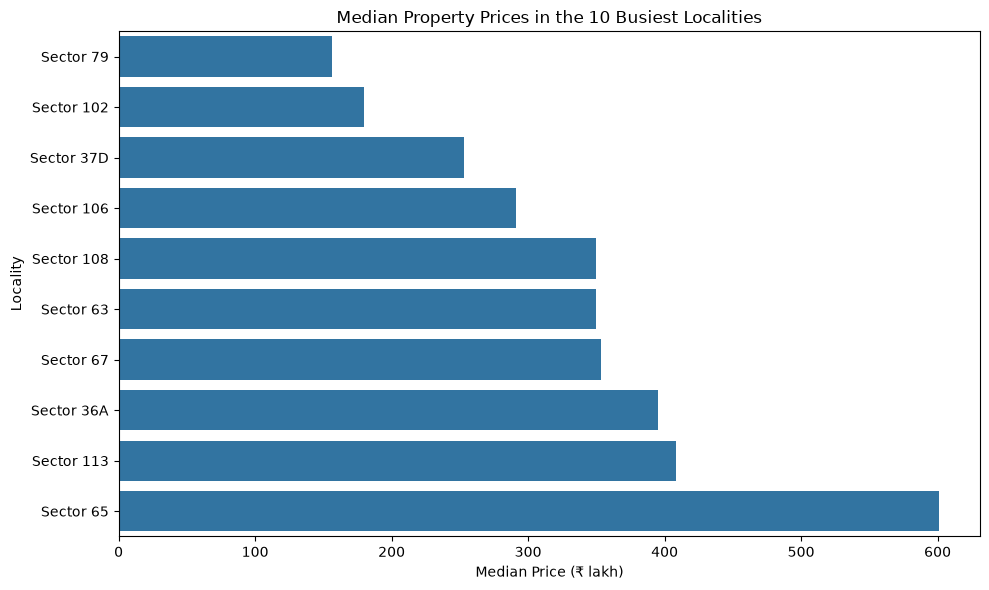

In [3]:
top_localities = (
    df.groupby("locality")
    .agg(
        listings=("price_lakh", "size"),
        median_price_lakh=("price_lakh", "median")
    )
    .nlargest(10, "listings")
    .sort_values("median_price_lakh")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_localities,
    x="median_price_lakh",
    y="locality",
    ax=ax
)

ax.set_title("Median Property Prices in the 10 Busiest Localities")
ax.set_xlabel("Median Price (₹ lakh)")
ax.set_ylabel("Locality")

plt.tight_layout()
fig.savefig(visuals_dir / "02_locality_median_prices.png", dpi=300, bbox_inches="tight")
plt.show()

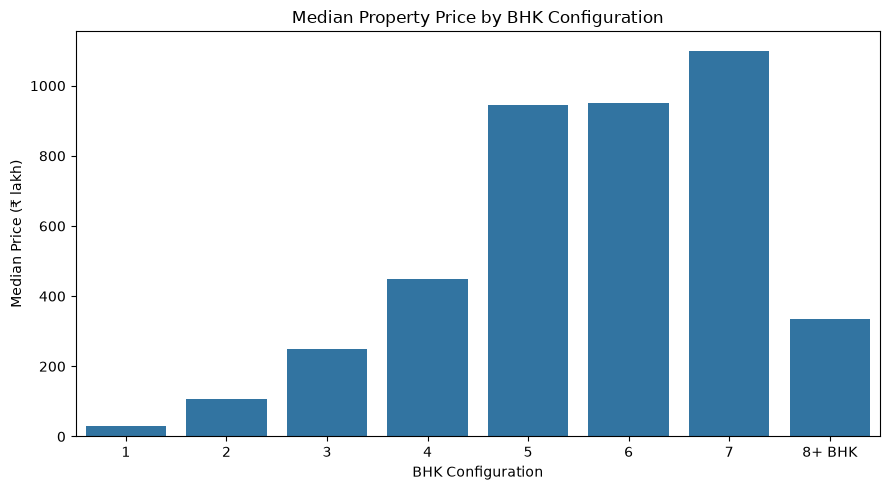

In [4]:
bhk_order = ["1", "2", "3", "4", "5", "6", "7", "8+ BHK"]

bhk_prices = (
    df[df["bhk_group"].isin(bhk_order)]
    .groupby("bhk_group", observed=True)
    .agg(
        listings=("price_lakh", "size"),
        median_price_lakh=("price_lakh", "median")
    )
    .reindex(bhk_order)
    .dropna(subset=["median_price_lakh"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=bhk_prices,
    x="bhk_group",
    y="median_price_lakh",
    order=bhk_order,
    ax=ax
)

ax.set_title("Median Property Price by BHK Configuration")
ax.set_xlabel("BHK Configuration")
ax.set_ylabel("Median Price (₹ lakh)")

plt.tight_layout()
fig.savefig(visuals_dir / "03_median_price_by_bhk.png", dpi=300, bbox_inches="tight")
plt.show()

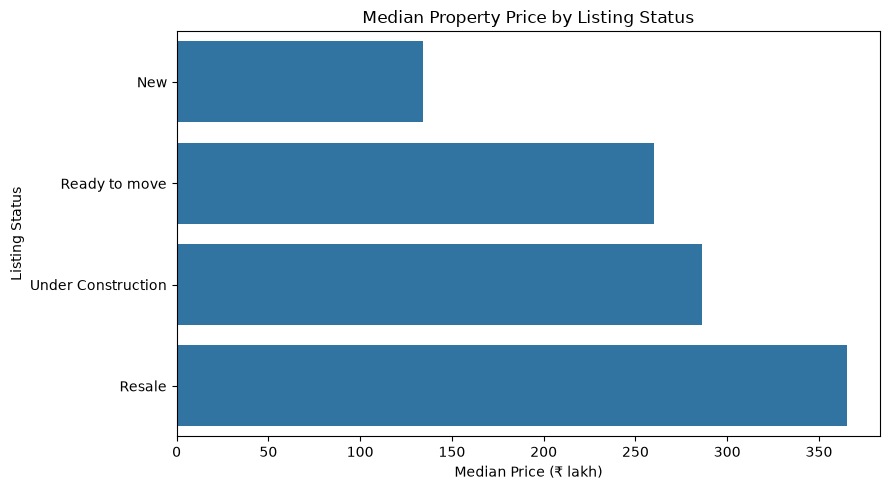

In [5]:
status_prices = (
    df.groupby("status")
    .agg(
        listings=("price_lakh", "size"),
        median_price_lakh=("price_lakh", "median")
    )
    .sort_values("median_price_lakh")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=status_prices,
    x="median_price_lakh",
    y="status",
    ax=ax
)

ax.set_title("Median Property Price by Listing Status")
ax.set_xlabel("Median Price (₹ lakh)")
ax.set_ylabel("Listing Status")

plt.tight_layout()
fig.savefig(visuals_dir / "04_median_price_by_status.png", dpi=300, bbox_inches="tight")
plt.show()

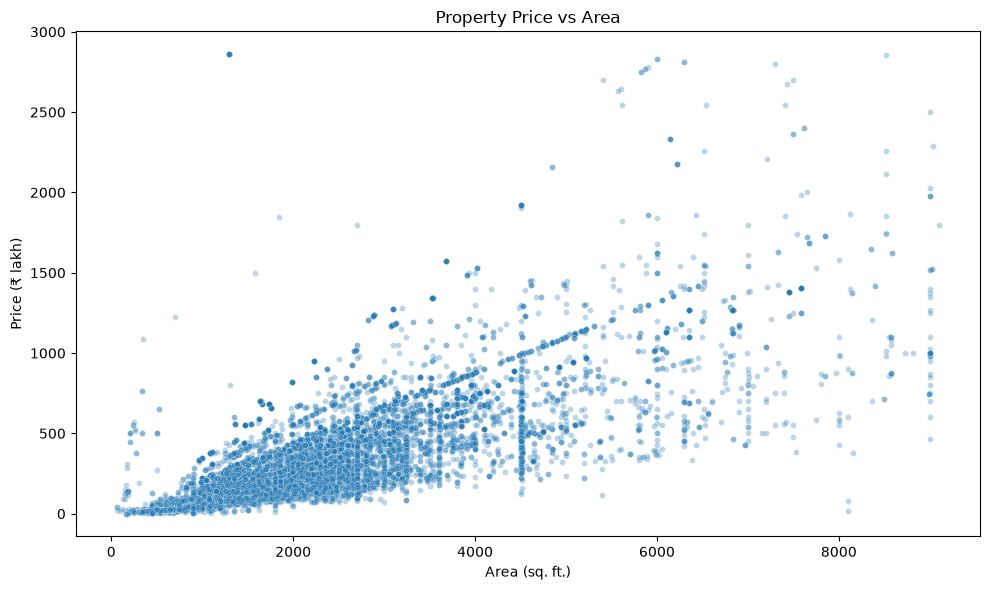

In [6]:
plot_df = df[
    (df["area_sqft"] <= df["area_sqft"].quantile(0.99)) &
    (df["price_lakh"] <= df["price_lakh"].quantile(0.99))
]

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="area_sqft",
    y="price_lakh",
    alpha=0.3,
    s=18,
    ax=ax
)

ax.set_title("Property Price vs Area")
ax.set_xlabel("Area (sq. ft.)")
ax.set_ylabel("Price (₹ lakh)")

plt.tight_layout()
fig.savefig(visuals_dir / "05_property_price_vs_area.png", dpi=300, bbox_inches="tight")
plt.show()

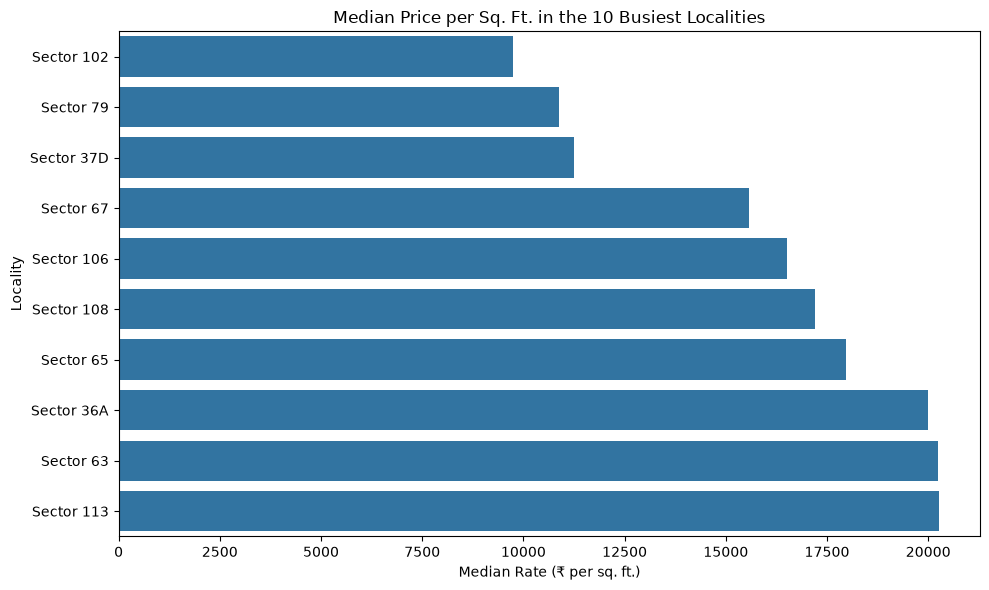

In [7]:
locality_rates = (
    df.groupby("locality")
    .agg(
        listings=("rate_per_sqft", "size"),
        median_rate=("rate_per_sqft", "median")
    )
    .query("listings >= 20")
    .nlargest(10, "listings")
    .sort_values("median_rate")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=locality_rates,
    x="median_rate",
    y="locality",
    ax=ax
)

ax.set_title("Median Price per Sq. Ft. in the 10 Busiest Localities")
ax.set_xlabel("Median Rate (₹ per sq. ft.)")
ax.set_ylabel("Locality")

plt.tight_layout()
fig.savefig(visuals_dir / "06_locality_median_rate.png", dpi=300, bbox_inches="tight")
plt.show()

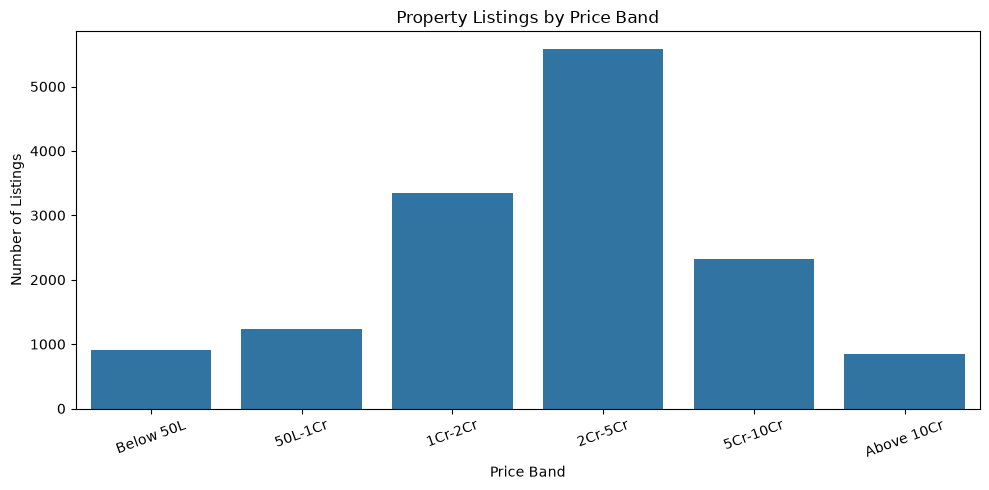

In [8]:
price_band_order = [
    "Below 50L",
    "50L-1Cr",
    "1Cr-2Cr",
    "2Cr-5Cr",
    "5Cr-10Cr",
    "Above 10Cr"
]

price_band_counts = (
    df["price_band"]
    .value_counts()
    .reindex(price_band_order)
    .rename_axis("price_band")
    .reset_index(name="listings")
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=price_band_counts,
    x="price_band",
    y="listings",
    ax=ax
)

ax.set_title("Property Listings by Price Band")
ax.set_xlabel("Price Band")
ax.set_ylabel("Number of Listings")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
fig.savefig(visuals_dir / "07_listings_by_price_band.png", dpi=300, bbox_inches="tight")
plt.show()

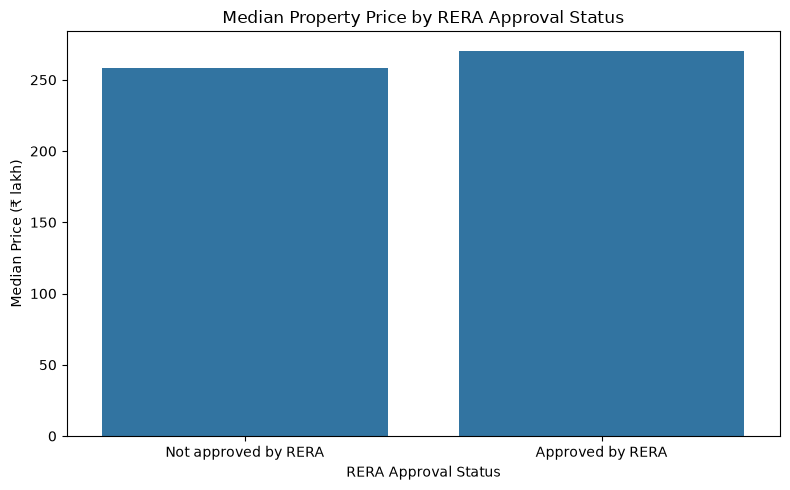

In [9]:
rera_prices = (
    df.groupby("rera_approval")
    .agg(
        listings=("price_lakh", "size"),
        median_price_lakh=("price_lakh", "median")
    )
    .sort_values("median_price_lakh")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=rera_prices,
    x="rera_approval",
    y="median_price_lakh",
    ax=ax
)

ax.set_title("Median Property Price by RERA Approval Status")
ax.set_xlabel("RERA Approval Status")
ax.set_ylabel("Median Price (₹ lakh)")

plt.tight_layout()
fig.savefig(visuals_dir / "08_median_price_by_rera_status.png", dpi=300, bbox_inches="tight")
plt.show()